In [6]:
import torch
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import torch.optim as optim
import matplotlib.pyplot as plt

from vae import VAE

In [7]:
# Dataset setup
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# CIFAR100 Dataset
dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
train_set, val_set = torch.utils.data.random_split(dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))])
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=False)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
# Loss function and optimization
def loss_fn(recon_x, x, mu, log_var):
    BCE = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence between the learned distribution and the standard normal distribution
    # We use mean and log_variance from encoder
    # Latent variable z = mu + std * eps
    KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KL

In [9]:
# Optimizer
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        # Forward pass
        encoded, mean, log_var = model.encoder(data)
        recon_data = model.decoder(encoded)
        # Compute loss
        loss = loss_fn(recon_data, data, mean, log_var)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss/len(train_loader)}')


Epoch [1/10], Loss: 40988.6758078125
Epoch [2/10], Loss: 29230.7792734375
Epoch [2/10], Loss: 29230.7792734375
Epoch [3/10], Loss: 26481.1351375
Epoch [3/10], Loss: 26481.1351375
Epoch [4/10], Loss: 26008.3597140625
Epoch [4/10], Loss: 26008.3597140625
Epoch [5/10], Loss: 19174.44421484375
Epoch [5/10], Loss: 19174.44421484375
Epoch [6/10], Loss: 16590.1149265625
Epoch [6/10], Loss: 16590.1149265625
Epoch [7/10], Loss: 16090.24785078125
Epoch [7/10], Loss: 16090.24785078125
Epoch [8/10], Loss: 15708.8724078125
Epoch [8/10], Loss: 15708.8724078125
Epoch [9/10], Loss: 15321.84786484375
Epoch [9/10], Loss: 15321.84786484375
Epoch [10/10], Loss: 14990.9091
Epoch [10/10], Loss: 14990.9091


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1394156..1.2575563].


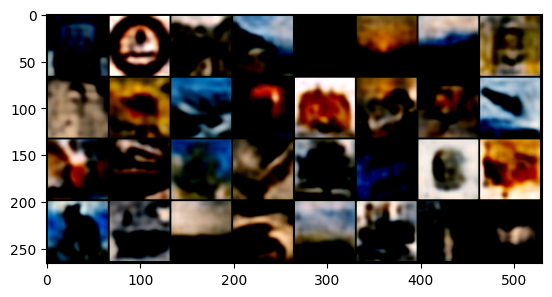

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


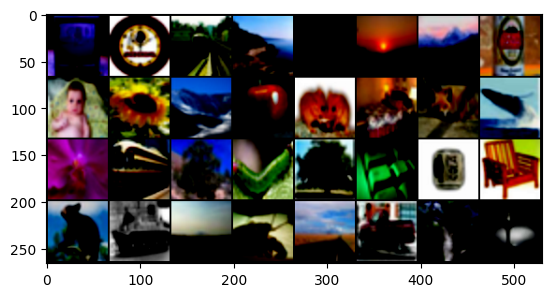

In [10]:
# Evaluation (visualize reconstructed images)
# show both reconstructed images and original images side by side
model.eval()
with torch.no_grad():
    sample_data, _ = next(iter(val_loader))
    reconstructed, encoded = model(sample_data.to(device))
    grid = torchvision.utils.make_grid(reconstructed.cpu())
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()
    # also show original images for comparison
    original_grid = torchvision.utils.make_grid(sample_data)
    plt.imshow(original_grid.permute(1, 2, 0))
    plt.show()